# Question 3: SMB Bundle Dashboard

## Assignment
> Flashforward to after the launch of the SMB Bundles.
>
> Thanks to your outreach prioritization we have done several subsequent  batches of calls, and bundle registrations have been coming in. In the third dataset you can find an overview of SMB sellers from both SYI and Pro, showing which bundle they purchased, with a start and end date.
>
> As a promotion, the first 28 days are for free. After that they pay:
>
> • €19.99 per 4 weeks for a Basic bundle
>
> • €49.99 per 4 weeks for a Plus bundle
>
> Every seller can only get a discount once. They can stop their bundle, or switch to another one at any point in the month. For this business case, assume they immediately pay for the full 4 weeks (unless it’s their first bundle ever and thus get a discount), and do not get a refund for any time left in their previous bundle.
>
> Design and present a dashboard that will help you show the impact of our Bundle introduction, and any other important analysis or metrics. The dashboard should both be useful at the launch and at the later stages. Use the data that is available to already fill parts of your dashboard design, while clearly stating what other data you would need to complete your view.

## Data Structure

In [78]:
import importlib

from IPython.display import display

import functions

functions = importlib.reload(functions)
pd = functions.pd
plt = functions.plt

functions.set_plot_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.1f}".format)


In [79]:
bundle_df = functions.load_q3_bundle_data()
launch_start, dashboard_reference_date = functions.q3_reference_dates(bundle_df)
seller_fields = functions.q3_seller_fields(bundle_df, dashboard_reference_date)
weekly_metrics = functions.q3_weekly_metrics(
    bundle_df,
    seller_fields,
    launch_start,
    dashboard_reference_date,
)
revenue_events = functions.q3_modeled_revenue_events(
    bundle_df,
    seller_fields,
    dashboard_reference_date,
)
revenue_4w = functions.q3_revenue_by_4_week_period(revenue_events, launch_start)
revenue_by_bundle = functions.q3_revenue_by_4_week_period_and_bundle(revenue_events, launch_start)
registrations_4w = functions.q3_registrations_by_4_week_period(seller_fields, launch_start)
cohort_metrics_28d = functions.q3_cohort_metrics(
    bundle_df,
    seller_fields,
    launch_start,
    dashboard_reference_date,
    cohort_window_days=28,
)
segment_metrics = functions.q3_segment_metrics(
    bundle_df,
    seller_fields,
    launch_start,
    dashboard_reference_date,
)


In [80]:
print(f"Dashboard reference date: {dashboard_reference_date:%Y-%m-%d}")
print(f"Launch start date: {launch_start:%Y-%m-%d}")

display(functions.q3_structure_summary(bundle_df, dashboard_reference_date))
display(functions.q3_distribution_summary(bundle_df))


Dashboard reference date: 2025-04-29
Launch start date: 2024-02-29


,Metric,Value
0,Rows,"8,830"
1,Unique sellers,"4,076"
2,Start date range,2024-02-29 to 2025-04-29
3,Finite end date range,2024-03-04 to 2025-04-29
4,Open-ended rows,"4,094"
5,Missing values,0
6,Duplicate rows,0
7,Sellers with potential overlapping intervals,18


,Field,Value,Rows
0,Customer type,SYI,6802
1,Customer type,Pro,2028
2,Bundle,Basic,3777
3,Bundle,No bundle,2728
4,Bundle,Plus,2325


## 1. Sales Overview

**Business question:** are SMB Bundles gaining commercial traction after launch?

**Dashboard view:** demand, monetized adoption, trial pipeline, modeled revenue, and Plus mix.

**What to read first:** the KPI strip uses the latest seller snapshot and latest complete 4-week periods where period completeness matters.

**Limitation:** revenue is modeled from bundle intervals and list prices. It is not actual invoiced or collected revenue.

In [81]:
display(
    functions.q3_sales_kpis(
        weekly_metrics,
        revenue_4w,
        dashboard_reference_date,
        registrations_4w,
    )
)

,KPI,Value
0,Reference date,2025-04-29
1,Active paid sellers,"2,709"
2,Active trial sellers,0
3,Latest complete 4-week registrations,35
4,Plus share of active paid sellers,40.9%
5,Latest complete modeled 4-week revenue,"€88,323"
6,Latest complete revenue period,2025-03-27


### Weekly New Registrations

**Business question:** is launch demand growing, stable, or fading?

**What we measure:** sellers whose first-ever Basic or Plus bundle starts in each week.

**What the chart shows:** demand volume and Basic/Plus mix over time.

**Why it matters:** registrations are the earliest signal of sales traction.

**Limitation:** registrations do not prove paid adoption because the first 28 days are free.

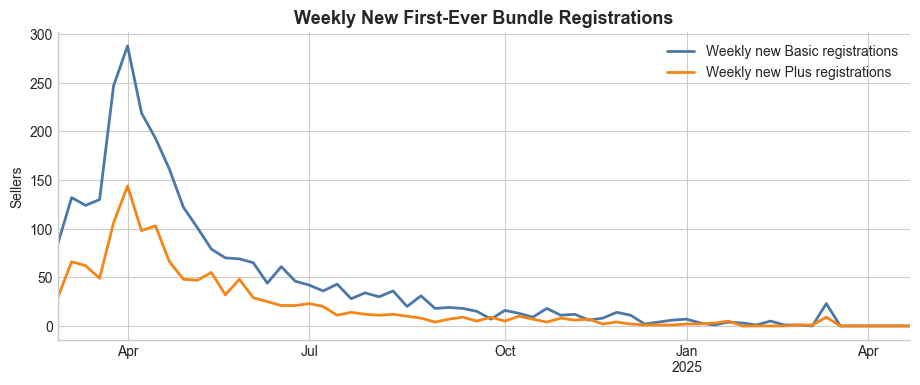

In [82]:
functions.plot_q3_weekly_new_registrations(weekly_metrics)
plt.show()


### Active Bundle Sellers

**Business question:** is the paid base building after the free trial?

**What we measure:** active Basic and Plus sellers, split into paid sellers and trial sellers.

**What the chart shows:** solid lines are paid sellers after day 28; dashed lines are trial sellers still inside the first 28 days.

**Why it matters:** this combines the monetized base and near-term paid pipeline in one view.

**Limitation:** active status is based on registration intervals, not payment collection records.

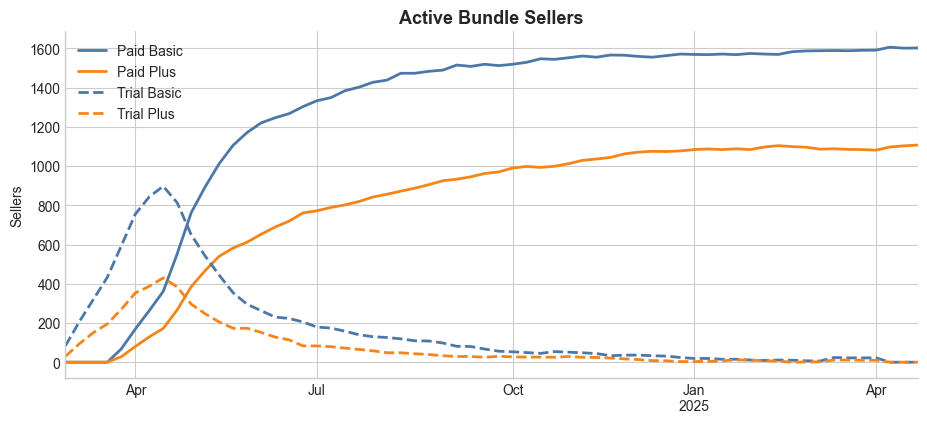

In [83]:
functions.plot_q3_active_bundle_sellers(weekly_metrics)
plt.show()

### Trial Pipeline Placeholder

**Business question:** how many active trial sellers are about to reach day 28?

**Metric to show:** active trial sellers by bundle type with trial end date in the next 7, 14, and 28 days.

**Suggested plot:** grouped bar chart by week of trial end, split by Basic trial and Plus trial.

**Why it matters:** this is the near-term conversion queue for sales and customer success follow-up.

**Current limitation:** as of the dashboard reference date, the file does not show an active near-term trial queue worth displaying as a populated module.

### Modeled Paid Revenue

**Business question:** is monetized adoption translating into subscription revenue?

**What we measure:** expected subscription revenue based on bundle status, list price, free-trial timing, and the no-refund switching assumption.

**What the chart shows:** 4-week modeled revenue periods anchored to launch. The final point is kept but marked as incomplete if the period is only partially observed.

**Why it matters:** this is the cleanest commercial value proxy available in the current dataset.

**Limitation:** this is modeled revenue, not actual invoiced or collected revenue.

,period_start,modeled_paid_revenue_eur,paid_billing_events
8,2024-10-10,"€84,963","2,670"
9,2024-11-07,"€87,303","2,727"
10,2024-12-05,"€87,573","2,721"
11,2025-01-02,"€88,243","2,738"
12,2025-01-30,"€88,723","2,744"
13,2025-02-27,"€88,073","2,734"
14,2025-03-27,"€88,323","2,745"
15,2025-04-24,"€21,044",646


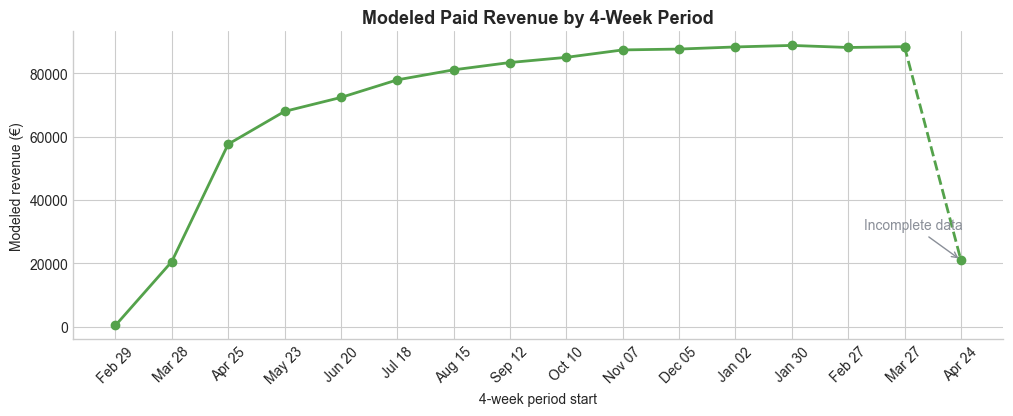

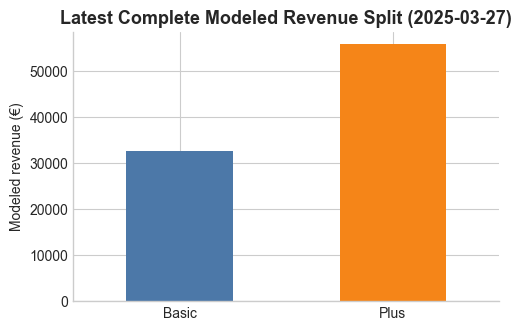

In [84]:
revenue_display = functions.format_display_table(
    revenue_4w.tail(8),
    euro_columns=["modeled_paid_revenue_eur"],
    integer_columns=["paid_billing_events"],
)
display(revenue_display)

functions.plot_q3_modeled_revenue(revenue_4w, dashboard_reference_date)
plt.show()
functions.plot_q3_latest_revenue_by_bundle(revenue_by_bundle, dashboard_reference_date)
plt.show()


### Plus Share

**Business question:** is adoption shifting toward the higher-priced bundle?

**What we measure:** active paid Plus sellers divided by all active paid bundle sellers.

**What the chart shows:** the paid mix between Plus and Basic over time.

**Why it matters:** Plus share measures monetization quality, not just adoption volume.

**Limitation:** this does not explain why sellers choose Plus; category, spend, and seller-size data would be needed.

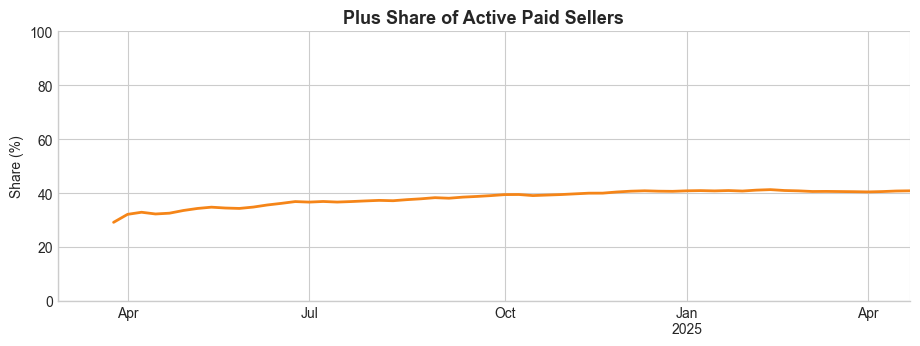

In [85]:
functions.plot_q3_plus_share(weekly_metrics)
plt.show()


## 2. Customer Quality

**Business question:** are registrations turning into retained paid customers?

**Dashboard view:** cohort health and segment diagnosis using only fields available in the registrations file.

**What to read first:** cohort rows define who is grouped together; maturity columns define how long those sellers have had to prove paid quality.

**Limitation:** this is early subscription quality only. It does not measure seller LTV or marketplace outcomes.

### Cohort Health

**Business question:** do cohorts remain active paid after the free trial and later billing cycles?

**Cohort aggregation:** rows group sellers whose first Basic or Plus bundle started in the same 28-day window from launch.

**Cohort maturity:** Day 28, Day 56, Day 84, and Day 112 are measured relative to each seller's own first bundle start. Blank cells are immature checkpoints, not zero conversion.

**What the heat-map shows:** darker cells indicate stronger active paid rates within the maturity columns.

**Limitation:** changes across cohorts at the same maturity can reflect seller mix, launch targeting, or small-sample noise. This dataset does not isolate the cause.

In [86]:
display(functions.q3_cohort_heatmap_table(cohort_metrics_28d))

,Cohort start,Cohort end,Aggregation window (days),Trial starters,Day 28 active paid rate,Day 56 active paid rate,Day 84 active paid rate,Day 112 active paid rate
0,2024-02-29,2024-03-27,28,749,88.1%,70.2%,66.6%,65.8%
1,2024-03-28,2024-04-24,28,"1,430",89.0%,71.9%,67.6%,66.4%
2,2024-04-25,2024-05-22,28,624,90.1%,71.0%,67.0%,65.4%
3,2024-05-23,2024-06-19,28,365,87.9%,71.5%,68.2%,66.6%
4,2024-06-20,2024-07-17,28,263,91.3%,75.3%,70.3%,68.1%
5,2024-07-18,2024-08-14,28,180,90.0%,71.7%,63.3%,63.3%
6,2024-08-15,2024-09-11,28,125,91.2%,77.6%,72.8%,68.8%
7,2024-09-12,2024-10-09,28,89,88.8%,82.0%,66.3%,64.0%
8,2024-10-10,2024-11-06,28,81,92.6%,67.9%,63.0%,61.7%
9,2024-11-07,2024-12-04,28,57,80.7%,68.4%,57.9%,59.6%


### Segment Diagnosis

**Business question:** where is adoption quality stronger?

**What we measure:** registrations, Day-28 paid conversion, Plus share, and active paid sellers by customer type and first bundle type.

**What the table shows:** compact sales-steering cuts for SYI vs Pro and Basic-first vs Plus-first sellers.

**Why it matters:** this helps identify where sales motion and bundle positioning look strongest.

**Limitation:** this is not an LTV or incrementality view; it uses only available registration fields.

In [87]:
segment_display = functions.q3_format_rate_table(
    segment_metrics,
    rate_columns=["Day-28 paid conversion", "Plus share of active paid sellers"],
    integer_columns=["Registrations", "Active paid sellers"],
)
display(segment_display)


,Customer type,First bundle type,Registrations,Day-28 paid conversion,Plus share of active paid sellers,Active paid sellers
0,Pro,Basic-first,621,90.0%,22.2%,396
1,Pro,Plus-first,318,88.4%,74.1%,220
2,SYI,Basic-first,"2,170",89.2%,26.4%,"1,449"
3,SYI,Plus-first,967,88.8%,73.4%,644


## 3. Business Impact

**Business question:** are bundles creating incremental value for Marktplaats and sellers?

**Dashboard view:** high-value future modules needed to complete the impact story.

**What current data supports:** launch traction, paid-base development, modeled subscription revenue, and early paid quality.

**What placeholders show:** the visual each future module should contain and the extra data required to build it.

**Limitation:** current registration data cannot prove incrementality, seller value uplift, or marketplace quality impact.

In [88]:
display(functions.q3_business_impact_placeholder_table())


,Module,Business question,Placeholder visual,Required data,Why it matters
0,Revenue impact,Is bundle revenue incremental?,"Revenue waterfall: new bundle revenue, lost fe...","Actual bundle invoices, collected revenue, ref...",Separates real growth from revenue shifted bet...
1,Controlled impact,What changed because of bundles?,Relative-time line: adopters vs matched non-ad...,"Pre/post seller history, comparable non-adopte...",Adds a counterfactual for credible impact claims
2,Seller value,Do sellers get better outcomes?,Indexed before/after line for leads per active ad,"Ad views, leads, messages, bids, phone clicks,...","Shows whether bundles create seller value, not..."
3,Sales steering,Where should launch effort focus?,"Compact segment table by category, seller size...","Seller category, active listings, historical s...",Turns dashboard findings into targeting and fo...
4,Marketplace guardrails,Are there quality risks as bundles scale?,Guardrail trend lines by bundle status,"Complaints, reported ads, duplicate/spam signa...",Keeps later-stage growth from hurting buyer ex...
